# EDA Step 1: 기초 통계 분석 (Basic Statistics)

**목표**: 데이터의 전체적인 구조와 기본 통계량을 파악합니다.

**분석 항목**:
- 데이터 Shape, 타입, 메모리 사용량
- 각 컬럼별 기술통계량 (mean, median, std 등)
- 결측치 현황 및 심각도 분류
- 컬럼 분류 (수치형/범주형/불리언)

> ⚠️ `survived`는 타겟 변수, `alive`는 사용 금지 (target leakage)

In [1]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# SEED 고정 (절대 변경 금지)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# 한글 폰트 설정 (환경에 따라 조정)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False

print('Setup complete!')

Setup complete!


## 1.1 데이터 로드

In [2]:
df = sns.load_dataset('titanic')

# 로컬 캐시용 CSV 저장 (다른 세션에서도 사용 가능)
df.to_csv('../data/titanic_raw.csv', index=False)

print(f'데이터 로드 완료!')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')

데이터 로드 완료!
Shape: 891 rows x 15 columns
Memory: 278.9 KB


## 1.2 데이터 미리보기

In [3]:
# 상위 5행
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# 하위 5행
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [5]:
# 랜덤 5행 (데이터 다양성 확인)
df.sample(5, random_state=SEED)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
709,1,3,male,NaN,1,1,15.2458,C,Third,man,True,NaN,Cherbourg,yes,False
439,0,2,male,31.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
840,0,3,male,20.0,0,0,7.9250,S,Third,man,True,NaN,Southampton,no,True
720,1,2,female,6.0,0,1,33.0000,S,Second,child,False,NaN,Southampton,yes,False
39,1,3,female,14.0,1,0,11.2417,C,Third,child,False,NaN,Cherbourg,yes,False


## 1.3 컬럼 정보 (Info)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
# 컬럼 분류표
col_info = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null': df.notnull().sum().values,
    'Null': df.isnull().sum().values,
    'Null%': (df.isnull().sum() / len(df) * 100).round(1).values,
    'Unique': df.nunique().values,
    'Sample': [str(df[col].dropna().iloc[0]) if df[col].notnull().any() else 'NaN' for col in df.columns]
})

# 컬럼 역할 분류
role_map = {
    'survived': 'TARGET',
    'alive': 'BANNED (target leak)',
    'pclass': 'Feature - Numeric/Ordinal',
    'sex': 'Feature - Categorical',
    'age': 'Feature - Numeric',
    'sibsp': 'Feature - Numeric',
    'parch': 'Feature - Numeric',
    'fare': 'Feature - Numeric',
    'embarked': 'Feature - Categorical',
    'class': 'CAUTION - pclass duplicate',
    'who': 'Feature - Categorical',
    'adult_male': 'Feature - Boolean',
    'deck': 'Feature - Categorical (sparse)',
    'embark_town': 'CAUTION - embarked duplicate',
    'alone': 'Feature - Boolean'
}
col_info['Role'] = col_info['Column'].map(role_map)

# 결측치 심각도
def severity(pct):
    if pct == 0: return 'Complete (Green)'
    elif pct < 5: return 'Mostly Complete (Yellow)'
    elif pct < 20: return 'Incomplete (Orange)'
    else: return 'Sparse (Red)'

col_info['Severity'] = col_info['Null%'].apply(severity)

col_info

,Column,Dtype,Non-Null,Null,Null%,Unique,Sample,Role,Severity
0,survived,int64,891,0,0.0,2,0,TARGET,Complete (Green)
1,pclass,int64,891,0,0.0,3,3,Feature - Numeric/Ordinal,Complete (Green)
2,sex,object,891,0,0.0,2,male,Feature - Categorical,Complete (Green)
3,age,float64,714,177,19.9,88,22.0,Feature - Numeric,Incomplete (Orange)
4,sibsp,int64,891,0,0.0,7,1,Feature - Numeric,Complete (Green)
5,parch,int64,891,0,0.0,7,0,Feature - Numeric,Complete (Green)
6,fare,float64,891,0,0.0,248,7.25,Feature - Numeric,Complete (Green)
7,embarked,object,889,2,0.2,3,S,Feature - Categorical,Mostly Complete (Yellow)
8,class,category,891,0,0.0,3,Third,CAUTION - pclass duplicate,Complete (Green)
9,who,object,891,0,0.0,3,man,Feature - Categorical,Complete (Green)


## 1.4 수치형 컬럼 기술통계량

In [8]:
# 수치형 컬럼 상세 통계
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'수치형 컬럼 ({len(numeric_cols)}개): {numeric_cols}')
print()

stats = df[numeric_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(3)
stats.loc['skew'] = df[numeric_cols].skew().round(3)
stats.loc['kurtosis'] = df[numeric_cols].kurtosis().round(3)
stats.loc['null_count'] = df[numeric_cols].isnull().sum()
stats.loc['zero_count'] = (df[numeric_cols] == 0).sum()
stats.loc['negative_count'] = (df[numeric_cols] < 0).sum()
stats

수치형 컬럼 (6개): ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']



,survived,pclass,age,sibsp,parch,fare
count,891.000,891.000,714.000,891.000,891.000,891.000
mean,0.384,2.309,29.699,0.523,0.382,32.204
std,0.487,0.836,14.526,1.103,0.806,49.693
min,0.000,1.000,0.420,0.000,0.000,0.000
1%,0.000,1.000,1.000,0.000,0.000,0.000
5%,0.000,1.000,4.000,0.000,0.000,7.225
25%,0.000,2.000,20.125,0.000,0.000,7.910
50%,0.000,3.000,28.000,0.000,0.000,14.454
75%,1.000,3.000,38.000,1.000,0.000,31.000
95%,1.000,3.000,56.000,3.000,2.000,112.079


## 1.5 범주형 컬럼 값 분포

In [9]:
# 범주형 + 불리언 컬럼
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print(f'범주형/불리언 컬럼 ({len(cat_cols)}개): {cat_cols}')
print()

for col in cat_cols:
    print(f'\n{"="*50}')
    print(f'[{col}] - Unique: {df[col].nunique()}, Null: {df[col].isnull().sum()}')
    print(f'{"="*50}')
    vc = df[col].value_counts(dropna=False)
    for val, cnt in vc.items():
        pct = cnt / len(df) * 100
        bar = '#' * int(pct / 2)
        print(f'  {str(val):20s}: {cnt:4d} ({pct:5.1f}%) {bar}')

범주형/불리언 컬럼 (9개): ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


[sex] - Unique: 2, Null: 0
  male                :  577 ( 64.8%) ################################
  female              :  314 ( 35.2%) #################

[embarked] - Unique: 3, Null: 2
  S                   :  644 ( 72.3%) ####################################
  C                   :  168 ( 18.9%) #########
  Q                   :   77 (  8.6%) ####
  nan                 :    2 (  0.2%) 

[class] - Unique: 3, Null: 0
  Third               :  491 ( 55.1%) ###########################
  First               :  216 ( 24.2%) ############
  Second              :  184 ( 20.7%) ##########

[who] - Unique: 3, Null: 0
  man                 :  537 ( 60.3%) ##############################
  woman               :  271 ( 30.4%) ###############
  child               :   83 (  9.3%) ####

[adult_male] - Unique: 2, Null: 0
  True                :  537 ( 60.3%) ##############################
  Fa

## 1.6 결측치 시각화

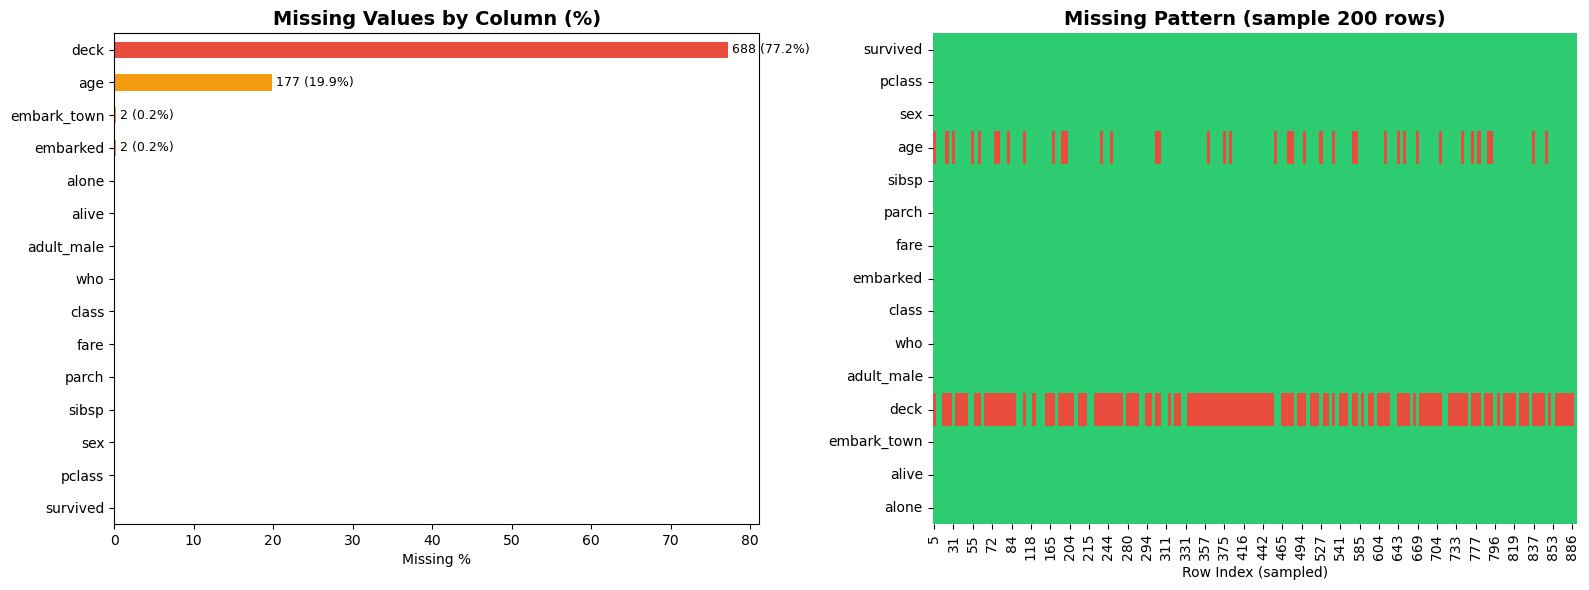

Saved: reports/eda_step1_missing.png


In [10]:
# 결측치 히트맵
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 결측치 비율 바 차트
missing = df.isnull().sum().sort_values(ascending=True)
missing_pct = (missing / len(df) * 100)
colors = ['#2ecc71' if p == 0 else '#f39c12' if p < 20 else '#e74c3c' for p in missing_pct]
missing_pct.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Missing %')
for i, (val, pct) in enumerate(zip(missing, missing_pct)):
    if val > 0:
        axes[0].text(pct + 0.5, i, f'{val} ({pct:.1f}%)', va='center', fontsize=9)

# 오른쪽: 결측치 히트맵 (상위 200행 샘플)
sample_idx = df.sample(min(200, len(df)), random_state=SEED).index.sort_values()
sns.heatmap(df.loc[sample_idx].isnull().T, cbar=False, ax=axes[1], 
            cmap=['#2ecc71', '#e74c3c'], yticklabels=True)
axes[1].set_title('Missing Pattern (sample 200 rows)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Row Index (sampled)')

plt.tight_layout()
plt.savefig('../reports/eda_step1_missing.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/eda_step1_missing.png')

## 1.7 데이터 타입 분포 요약

In [11]:
# 전체 데이터 프로파일 요약
print('='*60)
print('DATA PROFILE SUMMARY')
print('='*60)
print(f'Total Rows:     {len(df)}')
print(f'Total Columns:  {len(df.columns)}')
print()
print('Column Type Breakdown:')
print(f'  Numeric:     {len(df.select_dtypes(include=[np.number]).columns)} cols')
print(f'  Categorical: {len(df.select_dtypes(include=["object", "category"]).columns)} cols')
print(f'  Boolean:     {len(df.select_dtypes(include=["bool"]).columns)} cols')
print()
print('Missing Data Severity:')
null_pct = df.isnull().sum() / len(df) * 100
print(f'  Complete (0%):       {(null_pct == 0).sum()} cols')
print(f'  Yellow (<5%):        {((null_pct > 0) & (null_pct < 5)).sum()} cols')
print(f'  Orange (5-20%):      {((null_pct >= 5) & (null_pct < 20)).sum()} cols')
print(f'  Red (>20%):          {(null_pct >= 20).sum()} cols')
print()
print('Column Roles:')
print(f'  Target:    survived')
print(f'  BANNED:    alive (target leakage)')
print(f'  Features:  pclass, sex, age, sibsp, parch, fare, embarked,')
print(f'             who, adult_male, deck, alone')
print(f'  Duplicate: class (=pclass), embark_town (=embarked)')
print()
print('Key Observations:')
print(f'  - age: {df["age"].isnull().sum()} nulls ({df["age"].isnull().sum()/len(df)*100:.1f}%) - needs imputation')
print(f'  - deck: {df["deck"].isnull().sum()} nulls ({df["deck"].isnull().sum()/len(df)*100:.1f}%) - very sparse')
print(f'  - embarked: {df["embarked"].isnull().sum()} nulls - minimal')
print(f'  - fare has {(df["fare"]==0).sum()} zero values - investigate')
print(f'  - fare skewness: {df["fare"].skew():.2f} - highly right-skewed')

DATA PROFILE SUMMARY
Total Rows:     891
Total Columns:  15

Column Type Breakdown:
  Numeric:     6 cols
  Categorical: 7 cols
  Boolean:     2 cols

Missing Data Severity:
  Complete (0%):       11 cols
  Yellow (<5%):        2 cols
  Orange (5-20%):      1 cols
  Red (>20%):          1 cols

Column Roles:
  Target:    survived
  BANNED:    alive (target leakage)
  Features:  pclass, sex, age, sibsp, parch, fare, embarked,
             who, adult_male, deck, alone
  Duplicate: class (=pclass), embark_town (=embarked)

Key Observations:
  - age: 177 nulls (19.9%) - needs imputation
  - deck: 688 nulls (77.2%) - very sparse
  - embarked: 2 nulls - minimal
  - fare has 15 zero values - investigate
  - fare skewness: 4.79 - highly right-skewed


## 1.8 Safety Check

In [12]:
# 안전 점검: 금지 컬럼 확인
assert 'alive' in df.columns, 'alive 컬럼이 데이터에 존재해야 합니다 (사용은 금지)'
assert SEED == 42, 'SEED는 42로 고정!'

# alive = survived 동일성 검증
alive_check = (df['alive'] == 'yes').astype(int)
assert (alive_check == df['survived']).all(), 'alive와 survived가 일치하지 않음'
print('✅ Safety Check Passed!')
print('  - alive 컬럼은 survived와 100% 동일 → 절대 피처로 사용 금지')
print('  - SEED = 42 확인')

✅ Safety Check Passed!
  - alive 컬럼은 survived와 100% 동일 → 절대 피처로 사용 금지
  - SEED = 42 확인


---
## Summary

### 핵심 발견사항

1. **데이터 규모**: 891행 × 15열
2. **결측치 위험 컬럼**: `deck` (77.2%, Red), `age` (19.9%, Orange), `embarked` (0.2%, Yellow)
3. **fare 이상**: 0원 티켓 존재, 분포가 극심하게 오른쪽 치우침 (skew > 4)
4. **`alive` 금지 확인**: `survived`와 100% 동일 정보
5. **중복 컬럼**: `class`=`pclass`, `embark_town`=`embarked`

### 다음 단계
→ **EDA Step 2: 타겟 클래스 불균형 분석** 으로 진행